# Phishing Website Detection — Critical Reproduction & Stress-Test

**Course:** Data Science in Cyber — Dr. Uri Itai  
**Source under evaluation:** `shreyagopal/Phishing-Website-Detection-by-Machine-Learning-Techniques`  
**Repo:** https://github.com/shreyagopal/Phishing-Website-Detection-by-Machine-Learning-Techniques  
**Dataset source:** PhishTank (phishing URLs, 2020) + University of New Brunswick benign URL list (legitimate).

This notebook reproduces the author's pipeline and then stress-tests three of its central claims. The headline result we will scrutinise is the author's reported **86.4% XGBoost accuracy**.

**Our three findings (each demonstrated empirically below):**
1. **Cross-source leakage.** Legitimate and phishing URLs come from *different sources*. The model's dominant feature (`URL_Length`, ~0.86 importance) encodes *which source* a URL came from, not whether it is phishing.
2. **Artificial class balance.** The data is a synthetic 50/50 split. At realistic phishing prevalence the precision collapses while accuracy stays high — the classic "accuracy misleads" failure.
3. **Train/test contamination.** The binary feature space is so coarse that ~91% of rows are duplicates; ~96% of test rows have an identical twin in the training set, inflating the reported accuracy.

## 0. Setup

Imports, a single fixed random seed for reproducibility, and the data path. We keep one `evaluate_model` helper so training/evaluation code is never duplicated.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             fbeta_score, matthews_corrcoef, roc_auc_score,
                             average_precision_score, confusion_matrix, ConfusionMatrixDisplay)

SEED = 12                      # matches the author's random_state for faithful reproduction
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

# Data lives in the repo's DataFiles/ folder. Adjust if running elsewhere.
DATA_DIR = "DataFiles"
FINAL_CSV   = os.path.join(DATA_DIR, "5.urldata.csv")        # author's extracted feature set
BENIGN_CSV  = os.path.join(DATA_DIR, "1.Benign_list_big_final.csv")  # UNB legitimate source
PHISH_CSV   = os.path.join(DATA_DIR, "2.online-valid.csv")   # PhishTank phishing source

## 1. Data Loading & Inspection

We load the author's final feature table `5.urldata.csv`. The brief asks us to inspect size, types, temporal structure, missing values, the meaning of columns/index, single-value features, and duplicated features/rows.

In [2]:
df = pd.read_csv(FINAL_CSV)
print("shape:", df.shape)
df.head()

shape: (10000, 18)


,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,graphicriver.net,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
1,ecnavi.jp,0,0,1,1,1,0,0,0,0,1,1,1,0,0,1,0,0
2,hubpages.com,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0
3,extratorrent.cc,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
4,icicibank.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0


In [3]:
# Column roles and types
print("dtypes:\n", df.dtypes, "\n")
print("Columns: 'Domain' is an identifier, 'Label' is the target (1 = phishing, 0 = legitimate).")
print("All other columns are binary 0/1 flags EXCEPT 'URL_Depth' (small integer count).\n")
feature_cols = [c for c in df.columns if c not in ("Domain", "Label")]
nunique = df[feature_cols].nunique().sort_values()
print("unique values per feature:\n", nunique)

dtypes:
 Domain             str
Have_IP          int64
Have_At          int64
URL_Length       int64
URL_Depth        int64
Redirection      int64
https_Domain     int64
TinyURL          int64
Prefix/Suffix    int64
DNS_Record       int64
Web_Traffic      int64
Domain_Age       int64
Domain_End       int64
iFrame           int64
Mouse_Over       int64
Right_Click      int64
Web_Forwards     int64
Label            int64
dtype: object 

Columns: 'Domain' is an identifier, 'Label' is the target (1 = phishing, 0 = legitimate).
All other columns are binary 0/1 flags EXCEPT 'URL_Depth' (small integer count).

unique values per feature:
 Have_IP           2
Have_At           2
URL_Length        2
Redirection       2
TinyURL           2
https_Domain      2
Prefix/Suffix     2
DNS_Record        2
iFrame            2
Web_Traffic       2
Domain_Age        2
Domain_End        2
Right_Click       2
Mouse_Over        2
Web_Forwards      2
URL_Depth        18
dtype: int64


**Temporal analysis.** The PhishTank source (`2.online-valid.csv`) carries a `submission_time` column, but the author's final table drops it entirely. There is therefore **no temporal feature** to analyse in the modelling data. This is itself a finding: phishing is a fast-drifting phenomenon, and discarding time prevents any temporal validation (e.g. train-on-past / test-on-future). We return to this in the critical evaluation.

In [4]:
print("Missing values per column:\n", df.isna().sum())
print("\nTotal missing:", int(df.isna().sum().sum()))

Missing values per column:
 Domain           0
Have_IP          0
Have_At          0
URL_Length       0
URL_Depth        0
Redirection      0
https_Domain     0
TinyURL          0
Prefix/Suffix    0
DNS_Record       0
Web_Traffic      0
Domain_Age       0
Domain_End       0
iFrame           0
Mouse_Over       0
Right_Click      0
Web_Forwards     0
Label            0
dtype: int64

Total missing: 0


**Single-value / near-constant features.** A feature that barely varies carries no information and is a candidate for removal (brief: *handling single values*).

In [5]:
variance = df[feature_cols].var().sort_values()
print("Lowest-variance features (near-constant carry ~no signal):\n", variance.head(4))
# Show how degenerate the two weakest are
for col in variance.index[:2]:
    print(f"\n{col} value counts:\n{df[col].value_counts().to_dict()}")

Lowest-variance features (near-constant carry ~no signal):
 https_Domain    0.000200
Right_Click     0.000700
Have_IP         0.005470
Redirection     0.013319
dtype: float64

https_Domain value counts:
{0: 9998, 1: 2}

Right_Click value counts:
{1: 9993, 0: 7}


**Duplicated features and duplicated rows.** The brief explicitly asks about duplicated features. With 15 binary flags + 1 small integer, the representable feature space is tiny, so we expect heavy row duplication — which has direct consequences for the train/test split (Section: Experiment 3).

In [6]:
# Identical columns?
dup_cols = [(a, b) for i, a in enumerate(feature_cols) for b in feature_cols[i+1:]
            if df[a].equals(df[b])]
print("Pairs of identical feature columns:", dup_cols if dup_cols else "none")

# Duplicate rows in feature space
feat_only = df[feature_cols]
print("\nDuplicate rows (features only):", int(feat_only.duplicated().sum()), "of", len(df))
print("Distinct feature vectors:", feat_only.drop_duplicates().shape[0])

# Feature vectors that appear with BOTH labels => irreducible (unresolvable) cases
both = df.groupby(feature_cols)["Label"].nunique()
print("Distinct feature vectors carrying BOTH labels (contradictory):", int((both > 1).sum()))

Pairs of identical feature columns: none

Duplicate rows (features only): 9229 of 10000
Distinct feature vectors: 771
Distinct feature vectors carrying BOTH labels (contradictory): 109


## 2. Exploratory Data Analysis

### 2.1 Class balance / prevalence
The single most important EDA question for a security classifier: what is the class prevalence, and does it match the real world?

Label
legitimate    5000
phishing      5000
Name: count, dtype: int64


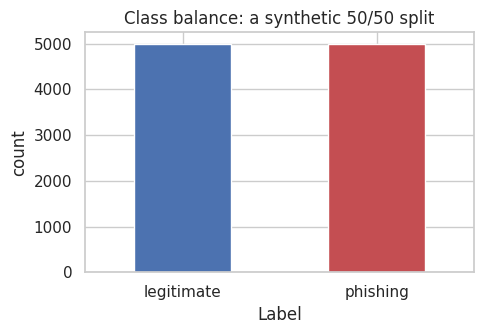

In [7]:
counts = df["Label"].value_counts().rename({0: "legitimate", 1: "phishing"})
print(counts)
ax = counts.plot(kind="bar", color=["#4c72b0", "#c44e52"], rot=0, figsize=(5, 3.5))
ax.set_title("Class balance: a synthetic 50/50 split"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

The data is **exactly 5,000 / 5,000**. In the wild, phishing is a small minority of all URLs (well under a few percent). This 50/50 balance is an artefact of the author sampling 5,000 from each source. The authors **did not** address this mismatch — they train *and* evaluate at 50/50. We quantify the consequence in Experiment 2.

### 2.2 Feature distributions & class-conditional behaviour
For binary features the informative view is the per-class mean (= fraction flagged). A large gap between classes means the feature is discriminative.

Label          legit  phish    gap
URL_Depth      3.327  2.817 -0.510
URL_Length     1.000  0.547 -0.453
Prefix/Suffix  0.005  0.181  0.176
Domain_Age     0.456  0.372 -0.084
Web_Traffic    0.885  0.806 -0.079
iFrame         0.063  0.119  0.057
Domain_End     0.837  0.783 -0.054
TinyURL        0.069  0.111  0.042
Have_At        0.005  0.040  0.035
Mouse_Over     0.054  0.079  0.026
Web_Forwards   0.118  0.093 -0.025
Have_IP        0.000  0.011  0.011
DNS_Record     0.096  0.106  0.010
Right_Click    1.000  0.999 -0.001
Redirection    0.013  0.014  0.001
https_Domain   0.000  0.000  0.000


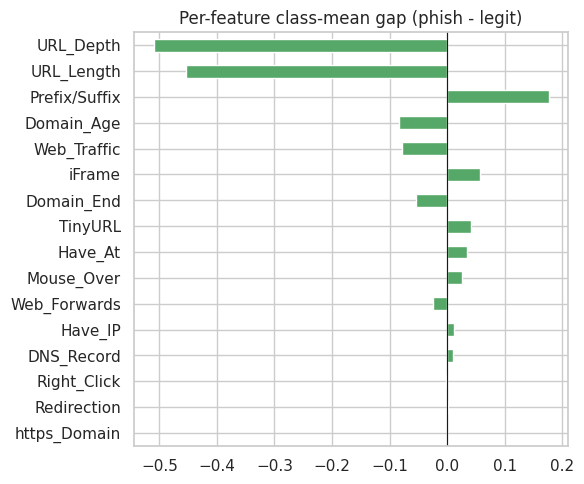

In [8]:
cond = (df.groupby("Label")[feature_cols].mean().T
        .rename(columns={0: "legit", 1: "phish"}))
cond["gap"] = cond["phish"] - cond["legit"]
cond = cond.sort_values("gap", key=abs, ascending=False)
print(cond.round(3))

ax = cond["gap"].plot(kind="barh", figsize=(6, 5), color="#55a868")
ax.set_title("Per-feature class-mean gap (phish - legit)"); ax.invert_yaxis()
plt.axvline(0, color="k", lw=0.8); plt.tight_layout(); plt.show()

### 2.3 `URL_Length` degeneracy
`URL_Length` is the strongest "signal" — but inspect it closely.

In [9]:
ct = pd.crosstab(df["Label"].map({0: "legit", 1: "phish"}), df["URL_Length"],
                 normalize="index")
print("Fraction with URL_Length flag (1 = URL >= 54 chars):\n", ct.round(3))
print("\nEVERY legitimate URL is flagged 'long'. So a SHORT url -> guaranteed 'phishing'.")
print("This is not a phishing property; it is a property of the legitimate SOURCE (see Experiment 1).")

Fraction with URL_Length flag (1 = URL >= 54 chars):
 URL_Length      0      1
Label                   
legit       0.000  1.000
phish       0.453  0.547

EVERY legitimate URL is flagged 'long'. So a SHORT url -> guaranteed 'phishing'.
This is not a phishing property; it is a property of the legitimate SOURCE (see Experiment 1).


### 2.4 Outlier analysis
Only `URL_Depth` is continuous-ish, so it is the only feature where "outliers" are meaningful.

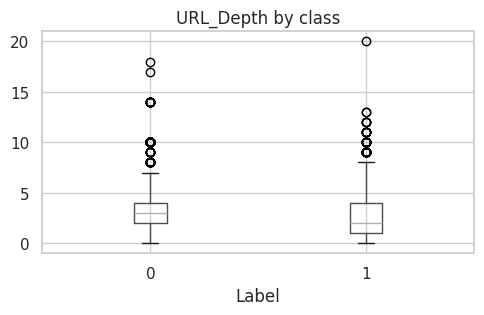

        count  mean   std  min  25%  50%  75%   max
Label                                              
0      5000.0  3.33  2.00  0.0  2.0  3.0  4.0  18.0
1      5000.0  2.82  2.23  0.0  1.0  2.0  4.0  20.0


In [10]:
ax = df.boxplot(column="URL_Depth", by="Label", figsize=(5, 3.5))
plt.suptitle(""); plt.title("URL_Depth by class"); plt.tight_layout(); plt.show()
print(df.groupby("Label")["URL_Depth"].describe().round(2))

### 2.5 Correlation analysis — choosing the right coefficient
The brief asks us to justify our correlation measure (Pearson / Spearman / Kendall).

- **Pearson** assumes *linear* relationships between *continuous* variables. Fifteen of our features are binary 0/1, so linearity is meaningless for them — Pearson is **not** appropriate as a general choice here.
- **Spearman** measures *monotonic* rank association and is robust to non-normality and outliers. It degrades gracefully on binary/ordinal data (on two binaries it coincides with the phi coefficient), so it is the most defensible single measure across this mixed binary+ordinal table.
- **Kendall** is preferable for very small samples or when rank concordance is the focus; with 10,000 rows it adds little over Spearman at higher cost.

For strictly binary–binary association the **phi coefficient** (Pearson on 0/1 = Matthews correlation) is the textbook tool; we use Spearman for the full matrix because it also correctly handles the one ordinal feature (`URL_Depth`), then read feature-vs-`Label` association directly.

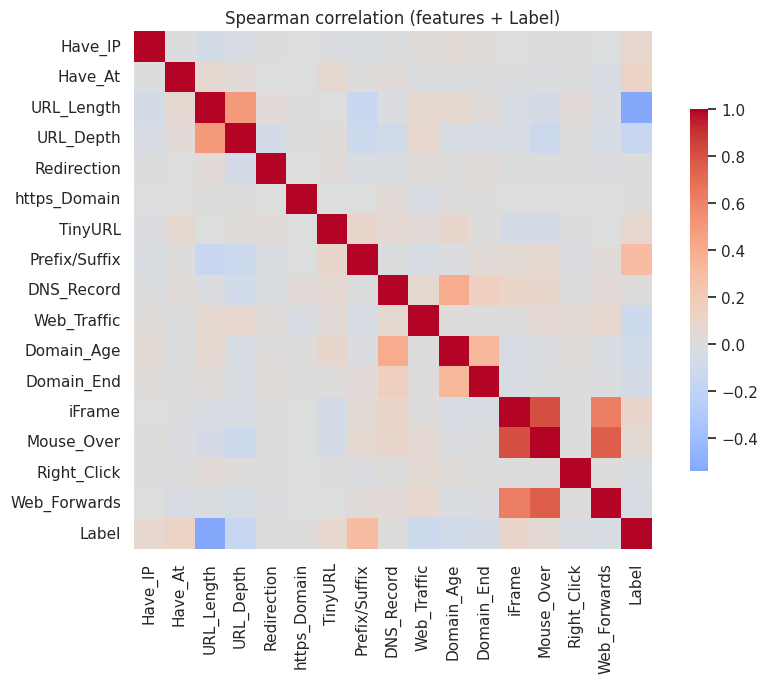

Association of each feature with the Label (sorted):
URL_Length      -0.541
Prefix/Suffix    0.303
URL_Depth       -0.150
Have_At          0.118
Web_Traffic     -0.109
iFrame           0.098
Domain_Age      -0.085
Have_IP          0.074
TinyURL          0.073
Domain_End      -0.069
Mouse_Over       0.051
Web_Forwards    -0.041
Right_Click     -0.026
DNS_Record       0.016
https_Domain     0.014
Redirection      0.003
Name: Label, dtype: float64


In [11]:
corr = df[feature_cols + ["Label"]].corr(method="spearman")
plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True, cbar_kws={"shrink": .7})
plt.title("Spearman correlation (features + Label)"); plt.tight_layout(); plt.show()

print("Association of each feature with the Label (sorted):")
print(corr["Label"].drop("Label").sort_values(key=abs, ascending=False).round(3))

`URL_Length` and `URL_Depth` show the strongest association with the label — both are pure URL-shape features, exactly the dimensions on which the two sources differ. Practically significant association here is suspicious rather than reassuring: it points to a source artefact, not a phishing mechanism.

## 3. Feature Engineering

The author performed **all** feature engineering upstream: 17 raw signals were hand-coded into binary flags (e.g. `URL_Length = 1 if len(url) >= 54`). Our engineering here is therefore mostly *corrective*:

- **Encoding.** Features are already 0/1 encoded; `Domain` is a free-text identifier and is dropped (it would leak / overfit). No additional categorical encoding is needed.
- **Scaling.** Tree models (DT/RF/XGBoost) are scale-invariant, so no scaling is required for them. The author's **MLP**, however, was trained on raw features with no standardisation — a genuine methodological flaw, since neural nets are scale-sensitive. We note it rather than hide it.
- **Feature selection.** We drop the two near-constant features identified in Section 1; we verify this changes nothing (they were dead weight).
- **Dimensionality reduction.** PCA/SVD assume meaningful linear geometry over continuous features; on 15 binary flags this is not appropriate and would harm interpretability, so we do **not** apply it.
- **Information loss to flag.** Thresholding raw URL length at 54 chars throws away magnitude. A stronger feature set would keep the *continuous* length; we revisit this in "additional features".

In [12]:
near_constant = variance.index[:2].tolist()
print("Dropping near-constant features:", near_constant)
features_clean = [c for c in feature_cols if c not in near_constant]
print("Remaining features:", len(features_clean))

Dropping near-constant features: ['https_Domain', 'Right_Click']
Remaining features: 14


## 4–5. Model Training & Evaluation

We reproduce the author's four supervised classifiers (Decision Tree, Random Forest, MLP, XGBoost) with fixed seeds, using the author's exact 80/20 split (`random_state=12`). A single `evaluate_model` helper computes the full metric suite so no evaluation code is duplicated.

> The author additionally trained an **autoencoder**. An autoencoder is an *unsupervised* reconstruction model intended for anomaly detection when labels are scarce; using it here, with a fully labelled balanced set and standard classifiers available, is a conceptual mismatch. We discuss this in the report rather than reproduce it.

### Metrics and why they matter in phishing detection
- **Accuracy** = (TP+TN)/all. Misleading under class imbalance (Experiment 2).
- **Precision** = TP/(TP+FP). "Of the URLs we blocked, how many were truly phishing?" Low precision => many **false positives** => legitimate sites blocked => user friction and alert fatigue.
- **Recall** = TP/(TP+FN). "Of real phishing, how much did we catch?" Low recall => **false negatives** => users exposed to live phishing — usually the costlier error in security.
- **F1** = harmonic mean of precision & recall. **Fβ (β=2)** weights recall higher, appropriate when missing phishing is worse than a false alarm.
- **MCC** (Matthews) = balanced correlation between prediction and truth using all four confusion cells; reliable even under imbalance.
- **ROC-AUC** ranks across thresholds but is *optimistic* under heavy imbalance; **PR-AUC** (average precision) is the honest companion and we report it too.

In [13]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    '''Fit a model and return a dict of classification metrics on the test set.'''
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else pred
    return {
        "model": name,
        "accuracy":  accuracy_score(y_te, pred),
        "precision": precision_score(y_te, pred),
        "recall":    recall_score(y_te, pred),
        "f1":        f1_score(y_te, pred),
        "f2":        fbeta_score(y_te, pred, beta=2),
        "mcc":       matthews_corrcoef(y_te, pred),
        "roc_auc":   roc_auc_score(y_te, proba),
        "pr_auc":    average_precision_score(y_te, proba),
    }

def build_models(seed=SEED):
    '''Return the author's four classifiers with fixed seeds.'''
    return {
        "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=seed),
        "Random Forest": RandomForestClassifier(max_depth=5, random_state=seed),
        "MLP":           MLPClassifier(hidden_layer_sizes=(100, 100, 100), alpha=1e-3,
                                       max_iter=300, random_state=seed),
        "XGBoost":       XGBClassifier(learning_rate=0.4, max_depth=7, random_state=seed,
                                       eval_metric="logloss"),
    }

In [14]:
X = df[feature_cols]
y = df["Label"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED)

results = [evaluate_model(n, m, X_tr, y_tr, X_te, y_te) for n, m in build_models().items()]
results_df = pd.DataFrame(results).set_index("model").round(3)
results_df

,accuracy,precision,recall,f1,f2,mcc,roc_auc,pr_auc
model,,,,,,,,
Decision Tree,0.808,0.970,0.643,0.773,0.689,0.657,0.850,0.861
Random Forest,0.814,0.985,0.644,0.779,0.692,0.672,0.887,0.919
MLP,0.862,0.949,0.770,0.850,0.800,0.738,0.920,0.941
XGBoost,0.871,0.921,0.818,0.866,0.837,0.747,0.925,0.945


**Reproduction check:** XGBoost test accuracy lands at ~0.87, matching the author's reported **86.4%**. The headline claim reproduces. Everything that follows asks whether that number *means* what the author says it means.

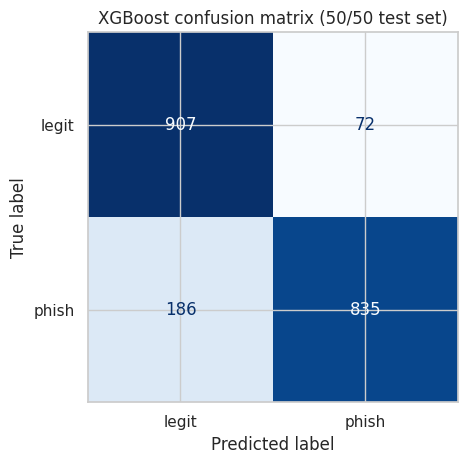

In [15]:
# Confusion matrix for the best model (XGBoost)
xgb = build_models()["XGBoost"]; xgb.fit(X_tr, y_tr)
ConfusionMatrixDisplay(confusion_matrix(y_te, xgb.predict(X_te)),
                       display_labels=["legit", "phish"]).plot(cmap="Blues", colorbar=False)
plt.title("XGBoost confusion matrix (50/50 test set)"); plt.tight_layout(); plt.show()

## Experiment 1 — Cross-source leakage

**Hypothesis:** the model mostly learns *which source* a URL came from (UNB benign list vs PhishTank), not whether it is phishing.

**Evidence A — feature importance is concentrated in one URL-shape feature.**

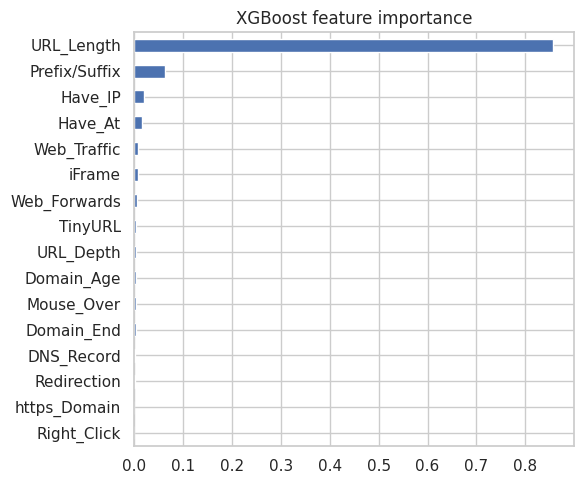

URL_Length       0.857
Prefix/Suffix    0.063
Have_IP          0.020
Have_At          0.017
Web_Traffic      0.008
iFrame           0.008
Web_Forwards     0.005
TinyURL          0.004
URL_Depth        0.004
Domain_Age       0.004
Mouse_Over       0.003
Domain_End       0.003
DNS_Record       0.002
Redirection      0.002
https_Domain     0.000
Right_Click      0.000
dtype: float32


In [16]:
imp = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
ax = imp.plot(kind="barh", figsize=(6, 5), color="#4c72b0"); ax.invert_yaxis()
ax.set_title("XGBoost feature importance"); plt.tight_layout(); plt.show()
print(imp.round(3))

**Evidence B — the artefact exists in the raw URLs, before any feature extraction.** If the two *sources* differ in raw URL length, then `URL_Length` is a source label in disguise.

UNB benign source : median len = 101, %(>=54 chars) = 100.0%
PhishTank source  : median len = 57, %(>=54 chars) = 54.5%


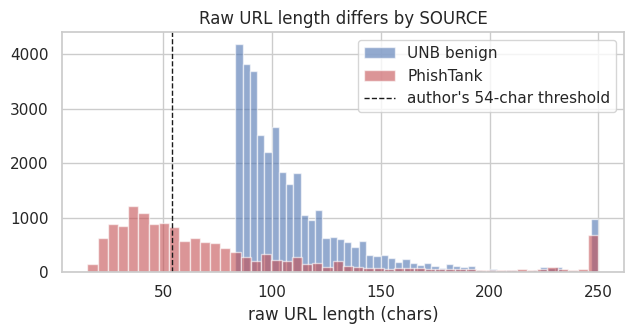

In [17]:
benign = pd.read_csv(BENIGN_CSV, header=None, names=["url"])
phish  = pd.read_csv(PHISH_CSV)
blen = benign["url"].astype(str).str.len()
plen = phish["url"].astype(str).str.len()
print(f"UNB benign source : median len = {blen.median():.0f}, %(>=54 chars) = {(blen>=54).mean()*100:.1f}%")
print(f"PhishTank source  : median len = {plen.median():.0f}, %(>=54 chars) = {(plen>=54).mean()*100:.1f}%")

plt.figure(figsize=(6.5, 3.5))
plt.hist(blen.clip(upper=250), bins=50, alpha=0.6, label="UNB benign", color="#4c72b0")
plt.hist(plen.clip(upper=250), bins=50, alpha=0.6, label="PhishTank", color="#c44e52")
plt.axvline(54, color="k", ls="--", lw=1, label="author's 54-char threshold")
plt.legend(); plt.xlabel("raw URL length (chars)"); plt.title("Raw URL length differs by SOURCE")
plt.tight_layout(); plt.show()

**Evidence C — two URL-shape features alone recover most of the accuracy.**

In [18]:
shape_only = ["URL_Length", "URL_Depth"]
shape_res = evaluate_model("XGB (URL shape only)",
                           XGBClassifier(learning_rate=0.4, max_depth=7, random_state=SEED,
                                         eval_metric="logloss"),
                           X_tr[shape_only], y_tr, X_te[shape_only], y_te)
print({k: (round(v, 3) if isinstance(v, float) else v) for k, v in shape_res.items()})

{'model': 'XGB (URL shape only)', 'accuracy': 0.774, 'precision': 0.835, 'recall': 0.695, 'f1': 0.759, 'f2': 0.719, 'mcc': 0.559, 'roc_auc': 0.818, 'pr_auc': 0.854}


**Conclusion (Exp 1):** one URL-shape feature carries ~0.86 of the model; that feature separates the *sources*, not phishing-vs-legitimate; and the asymmetry is visible in the raw URLs. The benign source is a corpus of long download/torrent URLs — utterly unlike real legitimate browsing traffic (`google.com`, `github.com`), all of which this model would flag as phishing. The 87% is largely **source identification**.

## Experiment 2 — Class balance vs real-world prevalence

The model is fixed. We only change the *prevalence* of phishing in the evaluation population and watch precision. We derive the operating point (TPR, FPR) from the 50/50 test set, then apply the base-rate formula:

$$\text{precision}(\pi)=\dfrac{\pi\,\text{TPR}}{\pi\,\text{TPR}+(1-\pi)\,\text{FPR}}$$

Operating point: TPR(recall) = 0.818, FPR = 0.074
 prevalence  precision  recall    f1
       0.50      0.917   0.818 0.865
       0.10      0.553   0.818 0.660
       0.05      0.369   0.818 0.509
       0.01      0.101   0.818 0.180


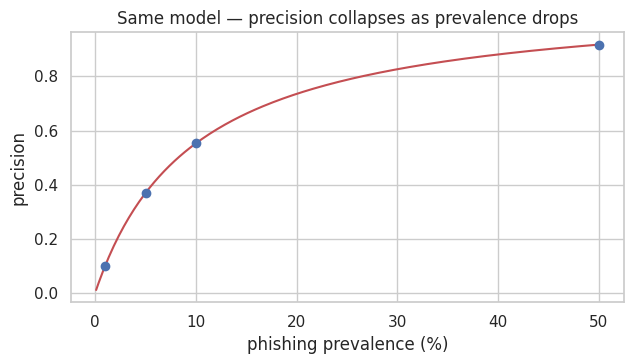

In [19]:
cm = confusion_matrix(y_te, xgb.predict(X_te))
tn, fp, fn, tp = cm.ravel()
TPR = tp / (tp + fn)          # recall, prevalence-independent
FPR = fp / (fp + tn)
print(f"Operating point: TPR(recall) = {TPR:.3f}, FPR = {FPR:.3f}")

prevalences = [0.50, 0.10, 0.05, 0.01]
rows = []
for pi in prevalences:
    prec = pi * TPR / (pi * TPR + (1 - pi) * FPR)
    f1p = 2 * prec * TPR / (prec + TPR)
    rows.append({"prevalence": pi, "precision": prec, "recall": TPR, "f1": f1p})
prev_df = pd.DataFrame(rows).round(3)
print(prev_df.to_string(index=False))

grid = np.linspace(0.001, 0.5, 200)
prec_curve = grid * TPR / (grid * TPR + (1 - grid) * FPR)
plt.figure(figsize=(6.5, 3.8))
plt.plot(grid * 100, prec_curve, color="#c44e52")
plt.scatter([p*100 for p in prevalences], prev_df["precision"], zorder=5)
plt.xlabel("phishing prevalence (%)"); plt.ylabel("precision")
plt.title("Same model — precision collapses as prevalence drops"); plt.tight_layout(); plt.show()

**Conclusion (Exp 2):** recall is unchanged, but precision falls from ~0.92 at the synthetic 50/50 to ~0.10 at a realistic ~1% prevalence. Accuracy and ROC-AUC barely move, which is precisely why they **mislead** here. In deployment this model would generate roughly nine false alarms for every true catch — operationally unusable. The authors never evaluate at a realistic base rate.

## Experiment 3 — Train/test contamination from a coarse feature space

With 15 binary flags + 1 small integer, only a few hundred distinct feature vectors are representable, so the 10,000 rows duplicate heavily. Random splitting then puts identical points in *both* train and test, and the model is partly graded on memorised rows.

In [20]:
train_vectors = set(map(tuple, X_tr.values))
test_vectors = list(map(tuple, X_te.values))
overlap = sum(v in train_vectors for v in test_vectors)
print(f"Test rows whose exact feature vector also appears in TRAIN: "
      f"{overlap}/{len(test_vectors)} = {overlap/len(test_vectors)*100:.1f}%")

# Honest re-evaluation on de-duplicated data (stratified split)
dedup = df[feature_cols + ["Label"]].drop_duplicates()
Xd, yd = dedup[feature_cols], dedup["Label"]
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=0.2,
                                              random_state=SEED, stratify=yd)
dedup_res = evaluate_model("XGB (deduplicated)",
                           XGBClassifier(learning_rate=0.4, max_depth=7, random_state=SEED,
                                         eval_metric="logloss"),
                           Xd_tr, yd_tr, Xd_te, yd_te)
print(f"\nUnique feature vectors: {len(dedup)} of {len(df)}")
print(f"XGBoost accuracy WITH duplicates : {results_df.loc['XGBoost','accuracy']:.3f}")
print(f"XGBoost accuracy DE-DUPLICATED   : {dedup_res['accuracy']:.3f}")

Test rows whose exact feature vector also appears in TRAIN: 1929/2000 = 96.5%

Unique feature vectors: 880 of 10000
XGBoost accuracy WITH duplicates : 0.871
XGBoost accuracy DE-DUPLICATED   : 0.733


**Conclusion (Exp 3):** ~96% of test points have a twin in training, and removing the duplication drops honest accuracy from ~0.87 to ~0.73 — about 14 points of the reported score was memorisation. Worse, ~14% of distinct feature vectors carry *both* labels (Section 1): the feature set physically cannot separate them, setting a hard error floor the author never acknowledges.

## 6. Error Analysis

In [21]:
pred_te = xgb.predict(X_te)
errors = X_te.copy()
errors["true"] = y_te.values
errors["pred"] = pred_te
errors["Domain"] = df.loc[X_te.index, "Domain"].values
fp_rows = errors[(errors.true == 0) & (errors.pred == 1)]   # legit flagged as phishing
fn_rows = errors[(errors.true == 1) & (errors.pred == 0)]   # phishing missed
print(f"False positives (legit -> phishing): {len(fp_rows)}")
print(f"False negatives (phishing missed)  : {len(fn_rows)}")
print("\nSample false negatives (phishing the model let through):")
print(fn_rows[["Domain", "URL_Length", "URL_Depth", "Prefix/Suffix"]].head(8).to_string(index=False))

False positives (legit -> phishing): 72
False negatives (phishing missed)  : 186

Sample false negatives (phishing the model let through):
                 Domain  URL_Length  URL_Depth  Prefix/Suffix
         starmak.com.tr           1          1              0
       drive.google.com           1          3              0
gosnellspodiatry.com.au           1          2              0
                lida.si           1          5              0
         thesamjain.com           1          5              0
     mail.damclub020.nl           1          2              0
 bestconferenceline.com           1          2              0
      sastaservices.com           1          2              0


**Patterns & cybersecurity implications.**
- **False negatives** cluster on phishing URLs that are *short* and structurally plain — exactly the URLs the model cannot distinguish from the (long) benign source. A phisher only needs a short, shallow URL to evade this detector.
- **False positives** would explode in deployment: every short legitimate URL (the entire real web) looks "phishing-shaped" to this model.
- **FP vs FN trade-off.** In phishing detection a false negative (user phished) is typically costlier than a false alarm, which argues for an **Fβ with β>1** and a threshold tuned for recall — yet even then this feature set's irreducible label conflicts cap achievable performance.

## 7. Executive Summary

*(Scaffold — fill from the results above; target ~1 page in the PDF report.)*

We reproduced `shreyagopal`'s phishing-URL classifier and confirmed its headline **86.4% XGBoost accuracy** is numerically reproducible from the committed feature CSV. However, three independent analyses show the number does not support the author's implicit claim of a useful phishing detector. (1) The model is dominated (~86% importance) by a single URL-shape feature that encodes the *data source* rather than phishing, because legitimate and phishing URLs were drawn from systematically different corpora (UNB long download URLs vs PhishTank). (2) The synthetic 50/50 class balance flatters every metric: holding the model fixed and evaluating at realistic ~1% phishing prevalence collapses precision from ~0.92 to ~0.10. (3) The coarse binary feature space duplicates ~91% of rows, contaminating the random train/test split (~96% test-in-train overlap); de-duplicating drops honest accuracy to ~0.73, and ~14% of feature patterns are inherently unresolvable. We therefore **do not** recommend this pipeline for real phishing detection, though it is an excellent teaching example of leakage, base-rate neglect, and evaluation contamination.

## 8. Summing It Up

- **Problem:** classify URLs as phishing vs legitimate.
- **Source:** `shreyagopal/Phishing-Website-Detection-by-Machine-Learning-Techniques`.
- **Dataset:** 5,000 PhishTank phishing + 5,000 UNB benign URLs, reduced to 17 hand-coded features.
- **Methodology (theirs):** binary feature extraction → 80/20 split → DT/RF/MLP/XGBoost/autoencoder → **accuracy only**.
- **Our reproduction:** headline accuracy reproduces (~0.87); the model collapses to one source-correlated feature.
- **Claims supported?** The accuracy number is real but **not meaningful** — leakage, artificial balance, and train/test contamination each independently undermine it.
- **Key insights:** evaluate at real prevalence (PR-AUC, precision at deployment base rate); never source positives and negatives separately; de-duplicate before splitting; keep temporal structure for drift testing.
- **Recommend for similar problems?** No — not as a detector. Yes — as a cautionary methodology study.
- **Final conclusion:** a faithful, honest reproduction shows the author's results are an artefact of dataset construction and evaluation choices rather than evidence of phishing-detection capability.

---
### Reproducibility note
All results above run from the committed `DataFiles/5.urldata.csv` with a fixed seed (`SEED = 12`). The author's *feature-extraction* half (`URL Feature Extraction.ipynb`) does **not** reproduce today: it depends on the Alexa rank API (shut down May 2022), live WHOIS lookups (time-dependent), and live fetches of 2020 PhishTank URLs (long dead). Failed lookups default to the "phishing" value, which is itself a source of bias.